# Step 4: DDS Labeling

Menghitung label kontrak terbaik NS menggunakan **Double Dummy Solver (DDS)**.

DDS menganalisis semua 20 kemungkinan kontrak (5 strain × 4 posisi) dengan asumsi semua pemain bermain sempurna. Kontrak NS dengan **skor bridge tertinggi** dipilih sebagai label target.

**Label yang dihasilkan:**
- `best_contract_strain`: C/D/H/S/N/P
- `best_contract_category`: partscore/game/small_slam/grand_slam/pass  
- `best_contract_level`: 1-7 (0 untuk pass)
- `best_contract_token`: teks kontrak, e.g. `4HN=`

**Prasyarat:**
- Jalankan `01_parsing.ipynb` terlebih dahulu
- DDS tersedia di `C:\dds\src\dds.dll`

In [1]:
import sys
import os

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, "src"))

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

DATA_PARSED    = Path(ROOT) / "data" / "parsed"
DATA_PROCESSED = Path(ROOT) / "data" / "processed"
RESULTS        = Path(ROOT) / "results"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
(RESULTS / "figures").mkdir(parents=True, exist_ok=True)

PARSED_CSV = DATA_PARSED / "parsed_boards.csv"
LABELED_CSV = DATA_PROCESSED / "labeled_boards.csv"

print(f"Root proyek : {ROOT}")
print("Setup selesai.")

Root proyek : d:\SkripsiBBO
Setup selesai.


In [2]:
df_parsed = pd.read_csv(PARSED_CSV)
print(f"Loaded: {df_parsed.shape[0]} baris dari parsed_boards.csv")

Loaded: 8632 baris dari parsed_boards.csv


## 4.1 Cek Ketersediaan DDS

In [3]:
from labeling import dds_available

DDS_AVAILABLE = dds_available()
if DDS_AVAILABLE:
    print("DDS tersedia! (C:\\dds\\src\\dds.dll via ctypes)")
    print("Labeling akan menggunakan double-dummy solver.")
else:
    print("DDS TIDAK tersedia.")
    print("Pastikan file ada di: C:\\dds\\src\\dds.dll")
    print("Fallback: gunakan bridge_features.csv dari Bridge_Prediction.")

DDS tersedia! (C:\dds\src\dds.dll via ctypes)
Labeling akan menggunakan double-dummy solver.


## 4.2 Demo DDS: Satu Board

Verifikasi DDS bekerja dengan benar sebelum labeling massal.

In [4]:
from labeling import compute_best_contract
from features import parse_hand

if DDS_AVAILABLE:
    sample = df_parsed.iloc[0]
    hands = {
        "N": parse_hand(str(sample["north_hand_norm"])),
        "S": parse_hand(str(sample["south_hand_norm"])),
        "E": parse_hand(str(sample["east_hand_norm"])),
        "W": parse_hand(str(sample["west_hand_norm"])),
    }
    vuln = str(sample.get("vulnerability_code", sample.get("vulnerability", "o")))

    result = compute_best_contract(hands, vuln)
    print("=== Hasil DDS untuk Board Sample ===")
    print(f"North    : {sample['north_hand_norm']}")
    print(f"South    : {sample['south_hand_norm']}")
    print(f"Vuln     : {sample.get('vulnerability', 'none')}")
    print()
    if result["is_pass"]:
        print("Kontrak terbaik NS: PASS (tidak ada kontrak NS yang menguntungkan)")
    else:
        print(f"Kontrak terbaik NS : {result['token']}")
        print(f"  Suit     : {result['strain']}")
        print(f"  Level    : {result['level']}")
        print(f"  Kategori : {result['category']}")
    print(f"\nKontrak BBO aktual : {sample['final_contract']}  (kontrak yang dimainkan)")
else:
    print("Lewati demo DDS — DLL tidak tersedia")

=== Hasil DDS untuk Board Sample ===
North    : SKT87HT76D873C743
South    : SJ9HAQ9DQJT96CJ95
Vuln     : both

Kontrak terbaik NS: PASS (tidak ada kontrak NS yang menguntungkan)

Kontrak BBO aktual : 3NT  (kontrak yang dimainkan)


## 4.3 Perbaikan Data Hilang

Parser menghasilkan 2 record per board (open + closed room).
Notebook ini memilih board yang lengkap untuk DDS dan menyimpan board yang masih rusak ke file terpisah.

In [5]:
from labeling import repair_missing_boards

df_unique, df_missing = repair_missing_boards(df_parsed)
missing_csv = RESULTS / "missing_boards.csv"

print(f"Total parsed             : {len(df_parsed)} records")
print(f"Board siap DDS           : {len(df_unique)} unique boards")
print(f"Board hilang/tidak valid  : {len(df_missing)} boards")
print(f"Dikurangi                : {len(df_parsed) - len(df_unique) - len(df_missing)} record")

if not df_missing.empty:
    df_missing.to_csv(missing_csv, index=False)
    print(f"Board tidak lengkap disimpan di: {missing_csv}")

Total parsed             : 8632 records
Board siap DDS           : 3662 unique boards
Board hilang/tidak valid  : 827 boards
Dikurangi                : 4143 record
Board tidak lengkap disimpan di: d:\SkripsiBBO\results\missing_boards.csv


## 4.4 Labeling Seluruh Dataset


In [6]:
from labeling import label_dataset_threaded, label_dataset

# Notebook path: use serial labeling by default to avoid DDS/thread instability on Windows.
# Enable threaded labeling only if you explicitly want to trade safety for speed.
USE_THREADED_LABELING = False

if DDS_AVAILABLE:
    if USE_THREADED_LABELING:
        print("Melabeli dengan DDS (paralel, threaded)...")
        df_labeled = label_dataset_threaded(df_unique, max_workers=4, progress_every=1000, verbose=True)
    else:
        print("Melabeli dengan DDS (serial, notebook-safe)...")
        df_labeled = label_dataset(df_unique, verbose=True, progress_every=1000)
    df_labeled.to_csv(LABELED_CSV, index=False)
    print(f"Label tersimpan di: {LABELED_CSV}")
    print(f"Shape: {df_labeled.shape}")
else:
    # Fallback ke Bridge_Prediction dataset
    BRIDGE_PRED_CSV = Path("d:/Bridge_Prediction/data/processed/bridge_features.csv")
    if BRIDGE_PRED_CSV.exists():
        print(f"Menggunakan fallback dataset: {BRIDGE_PRED_CSV}")
        df_labeled = pd.read_csv(BRIDGE_PRED_CSV)
        LABELED_CSV = BRIDGE_PRED_CSV
        print(f"Shape: {df_labeled.shape}")
    else:
        print("ERROR: DDS tidak tersedia dan fallback dataset tidak ditemukan.")
        df_labeled = None

Melabeli dengan DDS (serial, notebook-safe)...
DDS siap. Melabeli 3662 board...
  1000/3662 (27%) selesai
  2000/3662 (55%) selesai
  3000/3662 (82%) selesai

Selesai. Valid: 3662 | PASS: 695 | Gagal: 0
Label tersimpan di: d:\SkripsiBBO\data\processed\labeled_boards.csv
Shape: (3662, 25)


## 4.5 Distribusi Label DDS

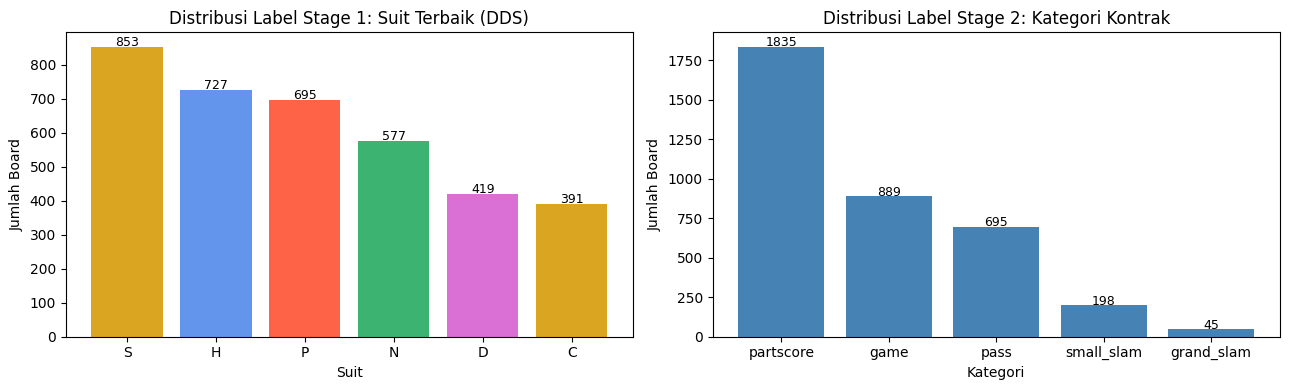


Distribusi label:
best_contract_strain
S    853
H    727
P    695
N    577
D    419
C    391

 best_contract_category
partscore     1835
game           889
pass           695
small_slam     198
grand_slam      45


In [7]:
if df_labeled is not None and "best_contract_strain" in df_labeled.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    strain_counts = df_labeled["best_contract_strain"].value_counts()
    axes[0].bar(strain_counts.index, strain_counts.values,
                color=["goldenrod","cornflowerblue","tomato","mediumseagreen","orchid"][:len(strain_counts)])
    axes[0].set_title("Distribusi Label Stage 1: Suit Terbaik (DDS)")
    axes[0].set_xlabel("Suit")
    axes[0].set_ylabel("Jumlah Board")
    for i, (k, v) in enumerate(strain_counts.items()):
        axes[0].text(i, v + 3, str(v), ha="center", fontsize=9)

    if "best_contract_category" in df_labeled.columns:
        cat_counts = df_labeled["best_contract_category"].value_counts()
        axes[1].bar(cat_counts.index, cat_counts.values, color="steelblue")
        axes[1].set_title("Distribusi Label Stage 2: Kategori Kontrak")
        axes[1].set_xlabel("Kategori")
        axes[1].set_ylabel("Jumlah Board")
        for i, (k, v) in enumerate(cat_counts.items()):
            axes[1].text(i, v + 3, str(v), ha="center", fontsize=9)

    plt.tight_layout()
    plt.savefig(RESULTS / "figures" / "label_distribution.png", dpi=150)
    plt.show()

    print("\nDistribusi label:")
    print(strain_counts.to_string())
    if "best_contract_category" in df_labeled.columns:
        print("\n", cat_counts.to_string())

---
## Output

File yang dihasilkan:
- `data/processed/labeled_boards.csv` — board dengan label DDS

**Langkah berikutnya:** Buka `05_dataset.ipynb` untuk persiapan dataset training.